# Neural Network From Scratch in NumPy

A fully connected regression network implemented with NumPy to connect the calculus of backpropagation with working, vectorized code.

## Project snapshot

| | |
|---|---|
| **Goal** | Implement forward propagation, backpropagation, and training without a deep-learning framework |
| **Data** | 1,000 synthetic nonlinear regression samples with three features |
| **Approach** | Two ReLU hidden layers, linear output, MSE loss, mini-batch gradient descent |
| **Evaluation** | MSE on an 80/20 train/validation split plus loss and predicted-vs-actual plots |
| **Result** | Saved run: train MSE `0.013468`; validation MSE `0.022930` |

The derivation is kept beside the implementation so tensor shapes, gradients, and parameter updates can be audited as one system.



## 1. Imports and plotting setup


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



## 2. Notation and shape conventions

To make the code match the math cleanly, I use **two different viewpoints**:

### External API
When calling `train(X, Y, ...)`:

- `X.shape = (n_samples, n_features)`
- `Y.shape = (n_samples, n_outputs)`

This is the most common shape in Python and machine learning libraries.

### Internal math representation
Inside the network, I transpose the data so that:

- `X_internal.shape = (n_features, m)`
- `Y_internal.shape = (n_outputs, m)`

where `m` is the number of examples in the current batch.

This matches the common textbook convention:

- **each column is one example**
- **each row is one feature / neuron output**

---

### Layer notation

Let:

- \(L\) = number of layers with trainable parameters
- \(n_l\) = number of neurons in layer \(l\)

For layer \(l\):

- \(W^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}\)
- \(b^{[l]} \in \mathbb{R}^{n_l \times 1}\)
- \(Z^{[l]} \in \mathbb{R}^{n_l \times m}\)
- \(A^{[l]} \in \mathbb{R}^{n_l \times m}\)

We also define:

- \(A^{[0]} = X\)

---

### Forward equations

For each layer \(l=1,\dots,L\):

\[
Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}
\]

For hidden layers:

\[
A^{[l]} = \mathrm{ReLU}(Z^{[l]})
\]

For the output layer in this notebook:

\[
A^{[L]} = Z^{[L]}
\]

So the prediction is:

\[
\hat{Y} = A^{[L]}
\]



## 3. Loss function

For regression, I use **Mean Squared Error**:

\[
J = \frac{1}{N}\sum (\hat{Y} - Y)^2
\]

where \(N\) is the total number of scalar output values in the batch.

If \(Y\) has shape \((n_{\text{out}}, m)\), then:

\[
N = n_{\text{out}} \cdot m
\]

The derivative with respect to the network output is:

\[
\frac{\partial J}{\partial A^{[L]}} = \frac{2}{N}(A^{[L]} - Y)
\]

Because the output layer is linear:

\[
A^{[L]} = Z^{[L]}
\quad\Longrightarrow\quad
\frac{\partial A^{[L]}}{\partial Z^{[L]}} = 1
\]

so:

\[
\delta^{[L]} = \frac{\partial J}{\partial Z^{[L]}} = \frac{2}{N}(A^{[L]} - Y)
\]



## 4. Backpropagation derivation

For each layer, define:

\[
\delta^{[l]} = \frac{\partial J}{\partial Z^{[l]}}
\]

This quantity has the same shape as \(Z^{[l]}\).

---

### Output layer

Since the output layer is linear:

\[
\delta^{[L]} = \frac{\partial J}{\partial A^{[L]}}
\]

For MSE:

\[
\delta^{[L]} = \frac{2}{N}(A^{[L]} - Y)
\]

---

### Parameter gradients

Because:

\[
Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}
\]

the gradients are:

\[
\frac{\partial J}{\partial W^{[l]}} = \delta^{[l]} (A^{[l-1]})^T
\]

\[
\frac{\partial J}{\partial b^{[l]}} = \sum_{\text{columns}} \delta^{[l]}
\]

That sum is taken across the batch dimension, since one bias vector is shared by all examples.

---

### Hidden-layer recursion

To move one layer backward:

\[
\frac{\partial J}{\partial A^{[l-1]}} = (W^{[l]})^T \delta^{[l]}
\]

For ReLU:

\[
\mathrm{ReLU}(z) = \max(0, z)
\]

\[
\mathrm{ReLU}'(z) =
\begin{cases}
1 & z > 0 \\
0 & z \le 0
\end{cases}
\]

So the recursive backprop step is:

\[
\delta^{[l-1]} =
\left( (W^{[l]})^T \delta^{[l]} \right)
\odot
\mathrm{ReLU}'(Z^{[l-1]})
\]

where \(\odot\) is elementwise multiplication.

---

### Gradient descent update

Once the gradients are computed, the parameters are updated by:

\[
W^{[l]} \leftarrow W^{[l]} - \eta \frac{\partial J}{\partial W^{[l]}}
\]

\[
b^{[l]} \leftarrow b^{[l]} - \eta \frac{\partial J}{\partial b^{[l]}}
\]

where \(\eta\) is the learning rate.



## 5. Activation functions and utilities

Below are the helper functions for:

- ReLU
- ReLU derivative
- MSE
- shape conversion helpers

The helpers make it easier to keep the public interface convenient while still using clean matrix math internally.


In [2]:

def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def prepare_X(X):
    """
    External shape: (n_samples, n_features)
    Internal shape: (n_features, m)
    """
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    return X.T


def prepare_Y(Y):
    """
    External shape: (n_samples, n_outputs) or (n_samples,)
    Internal shape: (n_outputs, m)
    """
    Y = np.asarray(Y, dtype=float)
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)
    return Y.T



## 6. Neural network implementation

A few implementation details are worth calling out:

### Parameter initialization

For ReLU networks, a common choice is **He initialization**:

\[
W^{[l]} \sim \mathcal{N}\left(0, \frac{2}{n_{l-1}}\right)
\]

In practice, I sample from a standard normal distribution and scale by:

\[
\sqrt{\frac{2}{n_{l-1}}}
\]

This helps keep activations from exploding or vanishing too quickly at initialization.

### Cached values for backpropagation

During the forward pass we save:

- `activations = [A0, A1, ..., AL]`
- `z_values = [Z1, Z2, ..., ZL]`

These are exactly the values needed for backpropagation later.


In [3]:

class NeuralNetwork:
    def __init__(self, input_size, output_size, hidden_layers=None, seed=None):
        if seed is not None:
            np.random.seed(seed)

        self.weights_list = []
        self.biases_list = []

        if hidden_layers is None:
            hidden_layers = []

        layer_sizes = [input_size] + hidden_layers + [output_size]

        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]

            # He initialization: good default for ReLU networks
            W = np.random.randn(out_dim, in_dim) * np.sqrt(2 / in_dim)

            # Biases are stored as column vectors: shape (out_dim, 1)
            b = np.zeros((out_dim, 1))

            self.weights_list.append(W)
            self.biases_list.append(b)

    # ---------------------------
    # Activation functions
    # ---------------------------
    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def output_activation(self, x):
        # Linear output layer for regression
        return x

    def output_activation_derivative(self, x):
        return np.ones_like(x)

    # ---------------------------
    # Loss
    # ---------------------------
    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    # ---------------------------
    # Shape helpers
    # ---------------------------
    def _prepare_X(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return X.T

    def _prepare_Y(self, Y):
        Y = np.asarray(Y, dtype=float)
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        return Y.T

    # ---------------------------
    # Forward pass
    # ---------------------------
    def forward(self, X_internal):
        """
        Parameters
        ----------
        X_internal : np.ndarray
            Shape: (n_features, m)

        Returns
        -------
        activations : list
            [A0, A1, ..., AL]
        z_values : list
            [Z1, Z2, ..., ZL]
        """
        A = X_internal
        activations = [A]
        z_values = []

        last_layer_index = len(self.weights_list) - 1

        for l, (W, b) in enumerate(zip(self.weights_list, self.biases_list)):
            # Linear step
            Z = W @ A + b
            z_values.append(Z)

            # Nonlinearity on hidden layers, linear output on last layer
            if l == last_layer_index:
                A = self.output_activation(Z)
            else:
                A = self.relu(Z)

            activations.append(A)

        return activations, z_values

    # ---------------------------
    # Backward pass (backpropagation)
    # ---------------------------
    def backward(self, Y_internal, activations, z_values):
        """
        Computes gradients for all layers.

        Y_internal shape: (n_outputs, m)
        """
        num_layers = len(self.weights_list)
        grad_W = [None] * num_layers
        grad_b = [None] * num_layers

        Y_hat = activations[-1]

        # For MSE averaged over all scalar outputs:
        # dJ/dY_hat = 2 * (Y_hat - Y) / Y.size
        dA = 2 * (Y_hat - Y_internal) / Y_internal.size

        # Output layer delta:
        # Since output activation is linear, derivative is 1
        dZ = dA * self.output_activation_derivative(z_values[-1])

        # Walk backward through layers
        for l in reversed(range(num_layers)):
            A_prev = activations[l]

            # dJ/dW[l] = dZ[l] @ A[l-1].T
            grad_W[l] = dZ @ A_prev.T

            # dJ/db[l] = sum over batch dimension (columns)
            grad_b[l] = np.sum(dZ, axis=1, keepdims=True)

            # Propagate to previous layer if we are not at the first layer
            if l > 0:
                dA_prev = self.weights_list[l].T @ dZ
                dZ = dA_prev * self.relu_derivative(z_values[l - 1])

        return grad_W, grad_b

    # ---------------------------
    # Gradient descent update
    # ---------------------------
    def update_parameters(self, grad_W, grad_b, learning_rate):
        for l in range(len(self.weights_list)):
            self.weights_list[l] -= learning_rate * grad_W[l]
            self.biases_list[l] -= learning_rate * grad_b[l]

    # ---------------------------
    # One optimization step on one batch
    # ---------------------------
    def train_on_batch(self, X_batch, Y_batch, learning_rate=0.01):
        X_internal = self._prepare_X(X_batch)
        Y_internal = self._prepare_Y(Y_batch)

        activations, z_values = self.forward(X_internal)
        Y_hat = activations[-1]

        loss = self.mse(Y_internal, Y_hat)

        grad_W, grad_b = self.backward(Y_internal, activations, z_values)
        self.update_parameters(grad_W, grad_b, learning_rate)

        return loss

    # ---------------------------
    # Full training loop
    # ---------------------------
    def train(
        self,
        X,
        Y,
        epochs=200,
        batch_size=32,
        learning_rate=0.01,
        shuffle=True,
        verbose=True
    ):
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)

        n_samples = X.shape[0]
        history = []

        for epoch in range(epochs):
            # Shuffle at the start of each epoch
            if shuffle:
                indices = np.random.permutation(n_samples)
                X_epoch = X[indices]
                Y_epoch = Y[indices]
            else:
                X_epoch = X
                Y_epoch = Y

            batch_losses = []

            # Mini-batch loop
            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_epoch[start:end]
                Y_batch = Y_epoch[start:end]

                loss = self.train_on_batch(X_batch, Y_batch, learning_rate)
                batch_losses.append(loss)

            epoch_loss = float(np.mean(batch_losses))
            history.append(epoch_loss)

            if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.6f}")

        return history

    # ---------------------------
    # Prediction
    # ---------------------------
    def predict(self, X):
        X_internal = self._prepare_X(X)
        activations, _ = self.forward(X_internal)
        Y_hat = activations[-1]
        return Y_hat.T  # Convert back to (n_samples, n_outputs)

    # ---------------------------
    # Introspection helper
    # ---------------------------
    def show_architecture(self):
        input_size = self.weights_list[0].shape[1]
        print(f"Input layer: {input_size} neurons")
        for i, (W, b) in enumerate(zip(self.weights_list, self.biases_list), start=1):
            print(
                f"Layer {i}: Weights shape = {W.shape}, Biases shape = {b.shape}"
            )



## 7. Create a synthetic dataset

To demonstrate that the network can learn a nonlinear relationship, I will generate a small regression dataset with three input features:

\[
y = \sin(1.5x_1) + 0.4x_2^2 - 0.3x_3 + \text{noise}
\]

This dataset is useful for validating the implementation because:

- it is **nonlinear**
- it is still easy to explain
- it shows why hidden layers matter


In [4]:

# Create a nonlinear synthetic regression dataset
n_samples = 1000
n_features = 3

X = np.random.uniform(-2.0, 2.0, size=(n_samples, n_features))

noise = 0.08 * np.random.randn(n_samples)
Y = (
    np.sin(1.5 * X[:, 0])
    + 0.4 * (X[:, 1] ** 2)
    - 0.3 * X[:, 2]
    + noise
).reshape(-1, 1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("First 3 samples:")
print(X[:3])
print(Y[:3])


X shape: (1000, 3)
Y shape: (1000, 1)
First 3 samples:
[[-0.50183952  1.80285723  0.92797577]
 [ 0.39463394 -1.37592544 -1.37602192]
 [-1.76766555  1.46470458  0.40446005]]
[[0.42286475]
 [1.77741643]
 [0.32078222]]



## 8. Create the train/validation split

Even for a simple from-scratch project, it is good practice to evaluate on data not used during training.

I will use an 80/20 split.


In [5]:

# Train / validation split
indices = np.random.permutation(n_samples)
split = int(0.8 * n_samples)

train_idx = indices[:split]
val_idx = indices[split:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]

print("Train shapes:", X_train.shape, Y_train.shape)
print("Validation shapes:", X_val.shape, Y_val.shape)


Train shapes: (800, 3) (800, 1)
Validation shapes: (200, 3) (200, 1)



## 9. Initialize the model

This network has:

- 3 input features
- two hidden layers with 32 neurons each
- 1 output neuron

That corresponds to the architecture:

\[
3 \rightarrow 32 \rightarrow 32 \rightarrow 1
\]


In [6]:

nn = NeuralNetwork(
    input_size=3,
    output_size=1,
    hidden_layers=[32, 32],
    seed=42
)

nn.show_architecture()


Input layer: 3 neurons
Layer 1: Weights shape = (32, 3), Biases shape = (32, 1)
Layer 2: Weights shape = (32, 32), Biases shape = (32, 1)
Layer 3: Weights shape = (1, 32), Biases shape = (1, 1)



## 10. Train the network

A few training hyperparameters:

- **epochs**: number of full passes through the training set
- **batch size**: how many samples are used for each gradient update
- **learning rate**: step size for gradient descent

With mini-batch gradient descent:

- `batch_size = 1` gives stochastic gradient descent
- `batch_size = n_samples` gives full-batch gradient descent
- values in between give mini-batch training


In [7]:

history = nn.train(
    X_train,
    Y_train,
    epochs=300,
    batch_size=32,
    learning_rate=0.01,
    shuffle=True,
    verbose=True
)


Epoch 1/300 - Loss: 0.398935


Epoch 31/300 - Loss: 0.106956


Epoch 61/300 - Loss: 0.071346


Epoch 91/300 - Loss: 0.044378


Epoch 121/300 - Loss: 0.032053


...

Epoch 181/300 - Loss: 0.022445


Epoch 211/300 - Loss: 0.019797


Epoch 241/300 - Loss: 0.017904


Epoch 271/300 - Loss: 0.015151


Epoch 300/300 - Loss: 0.014863



## 11. Evaluate the trained network

I will compute training and validation MSE, then inspect a few predictions.


In [8]:

train_preds = nn.predict(X_train)
val_preds = nn.predict(X_val)

train_mse = mse(Y_train, train_preds)
val_mse = mse(Y_val, val_preds)

print(f"Train MSE: {train_mse:.6f}")
print(f"Validation MSE: {val_mse:.6f}")

print("\nFirst 10 validation predictions vs targets:")
for pred, target in zip(val_preds[:10].flatten(), Y_val[:10].flatten()):
    print(f"pred = {pred: .4f} | target = {target: .4f}")


Train MSE: 0.013468
Validation MSE: 0.022930

First 10 validation predictions vs targets:
pred = -0.0225 | target = -0.1705
pred = -1.0423 | target = -0.9487
pred =  1.7087 | target =  2.0100
pred = -0.9653 | target = -0.6996
pred = -0.6111 | target = -0.7580
pred = -0.1537 | target = -0.0819
pred =  1.1592 | target =  1.1734
pred = -0.1017 | target = -0.1299
pred = -0.4846 | target = -0.4053
pred =  0.1613 | target = -0.2023



## 12. Inspect the training loss

A healthy training run should usually show the loss decreasing over time.  
Visualizing the loss curve makes convergence behavior easier to inspect and communicate.


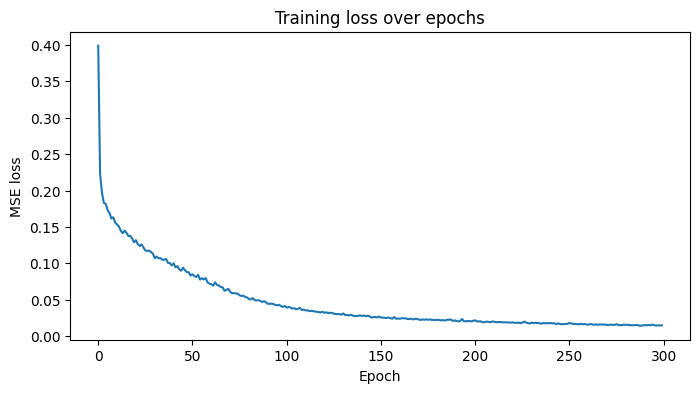

In [9]:

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss over epochs")
plt.show()



## 13. Compare predictions with targets

A simple sanity check is to compare predictions against the true targets.

If the model is learning well, the scatter plot should cluster around the line \(y=x\).


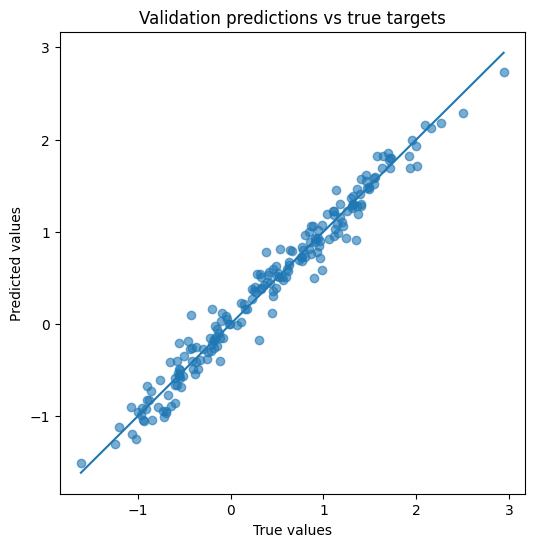

In [10]:

plt.figure(figsize=(6, 6))
plt.scatter(Y_val.flatten(), val_preds.flatten(), alpha=0.6)
min_v = min(Y_val.min(), val_preds.min())
max_v = max(Y_val.max(), val_preds.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Validation predictions vs true targets")
plt.show()


## Results and takeaways

The saved run reaches **0.013468 train MSE** and **0.022930 validation MSE** on the synthetic nonlinear task. The loss curve decreases across 300 epochs, while the predicted-vs-actual plot provides a visual check for residual spread and systematic bias.

The central implementation result is the direct mapping from mathematics to code: He initialization feeds the forward pass, cached activations support the chain rule, mini-batch gradients update every weight and bias, and the same public API handles training and inference.


## Limitations and next steps

- The evaluation uses one synthetic split; repeated seeds or cross-validation would better quantify variance.
- There is no numerical gradient check, which is the strongest next validation for custom backpropagation.
- The optimizer is plain gradient descent with no regularization, early stopping, or learning-rate schedule.
- Extend the output/loss pair to sigmoid plus binary cross-entropy and softmax plus multiclass cross-entropy.
- Add unit tests for layer shapes, gradient dimensions, invalid inputs, and reproducibility.
